In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Define the scenarios we simulated
scenarios = range(1, 11)
x_labels = [f"{i}v{i}" for i in scenarios]  # Creates labels like "1v1", "2v2", etc.

total_served_DPP = []
# total_target_DPP = []

total_served_RR = []
# total_target_RR = []

total_served_qos = []
total_served_static = []
total_served_static_15 = []
overall_ratios = []
gbr_ratios = []
nongbr_ratios = []

total_served_DPP_Static_1UE = []
total_served_DPP_Dynamic_1UE = []

# file_dir = "final_results_125mb_buffer"
# file_dir = 'final_results_buffer_937500bps_um_old'
# file_dir = 'final_results_buffer_um_937500_am_3125000'


simulations = range(1, 11)
# buffer = 937500
buffer = 937500
file_dir = f'final_results/buffer_{buffer}bps/'
savefigs= f'FIGS/{file_dir}'
save = True

if not os.path.exists(savefigs) and save:
    os.makedirs(savefigs)

thr_results_dpp = np.zeros((len(scenarios), len(simulations)))
thr_results_rr = np.zeros((len(scenarios), len(simulations)))

# ######### Throughput CALCULATION ################################

print("📊 Analyzing simulation results...")

for i in scenarios:
    for j in simulations:
        # Match the unified CSV name from your TMUX script
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)']
        served_DPP = normalized_throughput_ue_1.mean()
        total_served_DPP.append(served_DPP)
        thr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)']
        served_RR = normalized_throughput_RR.mean()
        # served_RR = normalized_throughput_RR.quantile(0.95)
        total_served_RR.append(served_RR)
        thr_results_rr[i-1, j-1] = served_RR


    

  

plt.figure(figsize=(10, 6))

# # Plot the three lines
plt.plot(x_labels, thr_results_dpp.mean(axis=1), marker='s', markersize=8, linewidth=2.5, 
         color='tab:blue', label='DPP Dynamic GFBR')
plt.plot(x_labels, thr_results_rr.mean(axis=1), marker='o', markersize=8, linewidth=2.5,
         color='black', linestyle='--', label='Round Robin')


plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Served Throughput (Mbps)')
# plt.legend(loc=6, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.9)
plt.title('Throughput for UE1 across Scenarios, DPP vs Round Robin',  fontweight='bold')
# Save the plot
plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE.pdf', dpi=300, bbox_inches='tight')

print('Throughput_DPP:' , thr_results_dpp.mean(axis=1).round(2))
print('Throughput_RR:' , thr_results_rr.mean(axis=1).round(2))


# ######### DROPRATE CALCULATION ################################


total_served_DPP = []
# total_target_DPP = []

total_served_RR = []
# total_target_RR = []

total_served_qos = []
total_served_static = []
total_served_static_15 = []
overall_ratios = []
gbr_ratios = []
nongbr_ratios = []

total_served_DPP_Static_1UE = []
total_served_DPP_Dynamic_1UE = []

dr_results_dpp = np.zeros((len(scenarios), len(simulations)))
dr_results_rr = np.zeros((len(scenarios), len(simulations)))




# # file_dir = "final_results_125mb_buffer"
# # file_dir = 'final_results_buffer_937500bps_um_old'
# file_dir = 'final_results_buffer_um_937500_am_3125000'



# print("📊 Analyzing simulation results...")

for i in scenarios:
    for j in simulations:
        # Match the unified CSV name from your TMUX script
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic = df_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop = 1 - (normalized_throughput_ue_1 / requested_traffic)
        served_DPP = drop.mean()*100
        total_served_DPP.append(served_DPP)
        dr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic_RR = df_RR_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop_RR = 1 - (normalized_throughput_RR / requested_traffic_RR)
        served_RR = drop_RR.mean()*100
        # served_RR = normalized_throughput_RR.quantile(0.95)
        total_served_RR.append(served_RR)
        dr_results_rr[i-1, j-1] = served_RR



    

  

plt.figure(figsize=(10, 6))

# # Plot the three lines
plt.plot(x_labels, dr_results_dpp.mean(axis=1), marker='s', markersize=8, linewidth=2.5, 
         color='tab:blue', label='DPP Dynamic GFBR')
plt.plot(x_labels, dr_results_rr.mean(axis=1), marker='o', markersize=8, linewidth=2.5,
         color='black', linestyle='--', label='Round Robin')


plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Droprate [%]')
# plt.legend(loc=6, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.9)
plt.title('Droprate for UE1 across Scenarios, DPP vs Round Robin',  fontweight='bold')
plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE.pdf', dpi=300, bbox_inches='tight')

print('Droprate_DPP:' , dr_results_dpp.mean(axis=1).round(2))
print('Droprate_RR:' , dr_results_rr.mean(axis=1).round(2))


# ######### Delay CALCULATION ################################


print("📊 Analyzing simulation results...")

total_delay_ue1_DPP = []
total_delay_ue1_RR = []
total_delay_ue1_QoS = []
total_delay_ue1_static = []
total_delay_ue1_static_15 = []

gbr_max_value_list= []
gbr_min_value_list= []

RR_max_value_list= []
RR_min_value_list= []

delay_results_dpp = np.zeros((len(scenarios), len(simulations)))
delay_results_rr = np.zeros((len(scenarios), len(simulations)))
quantile_95_dpp = np.zeros((len(scenarios), len(simulations)))
quantile_95_rr = np.zeros((len(scenarios), len(simulations)))
quantile_05_dpp = np.zeros((len(scenarios), len(simulations)))
quantile_05_rr = np.zeros((len(scenarios), len(simulations)))

for i in scenarios:
    for j in simulations:
    # Match the unified CSV name from your TMUX script
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
       

        
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredDelay(ms)'].mean()

        gbr_max_value_list.append(df_ue_id_1['MeasuredDelay(ms)'].quantile(0.95))
        gbr_min_value_list.append(df_ue_id_1['MeasuredDelay(ms)'].quantile(0.05))
        quantile_95_dpp[i-1, j-1] = df_ue_id_1['MeasuredDelay(ms)'].quantile(0.95)
        quantile_05_dpp[i-1, j-1] = df_ue_id_1['MeasuredDelay(ms)'].quantile(0.05)
        
        total_delay_ue1_DPP.append(normalized_throughput_ue_1)
        delay_results_dpp[i-1, j-1] = normalized_throughput_ue_1

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        delay_ue1_RR = df_RR_ue_id_1['MeasuredDelay(ms)']
        delay_mean_RR = delay_ue1_RR.mean()
        total_delay_ue1_RR.append(delay_mean_RR)
        delay_results_rr[i-1, j-1] = delay_mean_RR

        RR_max_value_list.append(df_RR_ue_id_1['MeasuredDelay(ms)'].quantile(0.95))
        RR_min_value_list.append(df_RR_ue_id_1['MeasuredDelay(ms)'].quantile(0.05))
        quantile_95_rr[i-1, j-1] = df_RR_ue_id_1['MeasuredDelay(ms)'].quantile(0.95)
        quantile_05_rr[i-1, j-1] = df_RR_ue_id_1['MeasuredDelay(ms)'].quantile(0.05)


plt.figure(figsize=(10, 6))
# Plot the three lines
plt.plot(x_labels, delay_results_dpp.mean(axis=1), marker='s', markersize=8, linewidth=2.5, 
         color='tab:blue', label='DPP UE1 Delay')
plt.plot(x_labels, delay_results_rr.mean(axis=1), marker='o', markersize=8, linewidth=2.5,
         color='black', linestyle='--', label='Round Robin UE1 Delay')

plt.fill_between(x_labels, quantile_05_dpp.mean(axis=1), quantile_95_dpp.mean(axis=1), color='tab:blue', alpha=0.1)
plt.fill_between(x_labels, quantile_05_rr.mean(axis=1), quantile_95_rr.mean(axis=1), color='black', alpha=0.1)


plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')

# Add a horizontal dashed line representing a typical 4K video delay limit (e.g., 20ms or 40ms)
plt.axhline(y=150, color='green', linestyle='--', alpha=0.7, label='3GPP 5QI 2 (VIDEO) Delay Budget (150ms)')
plt.ylabel('Delay (ms)' )
# plt.legend(loc=6)
plt.grid(True, linestyle=':', alpha=0.9)
plt.title('Delay for UE1 across Scenarios DPP vs Round Robin',  fontweight='bold')
plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE.pdf', dpi=300, bbox_inches='tight')



print('Delay_DPP:' , delay_results_dpp.mean(axis=1).round(2))
print('Delay_RR:' , delay_results_rr.mean(axis=1).round(2))
    

📊 Analyzing simulation results...
Throughput_DPP_Mean: [25.88 25.88 25.88 25.88 25.53 25.42 25.1  25.04 24.5  23.9 ]
Throughput_RR_Mean: [25.67 24.88 22.86 21.9  20.36 18.72 17.37 16.55 15.53 12.44]
Droprate_DPP_Mean: [0.16 0.17 0.18 0.17 1.52 1.96 3.18 3.42 5.48 7.8 ]
Droprate_RR_Mean: [ 0.98  4.03 11.82 15.53 21.45 27.78 32.99 36.17 40.08 52.01]
Delay_DPP_Mean: [ 2.22  2.35  2.45  2.56  3.63  4.74  6.78  7.45  8.68 12.39]
Delay_RR_Mean: [ 2.47  3.92  7.06  8.86 11.19 14.42 19.4  21.64 23.74 34.06]


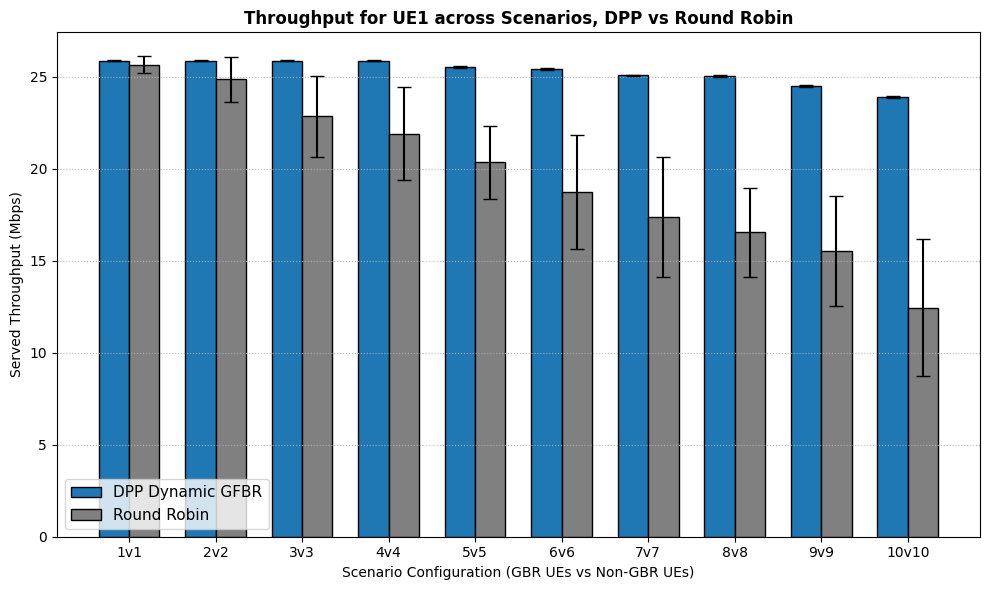

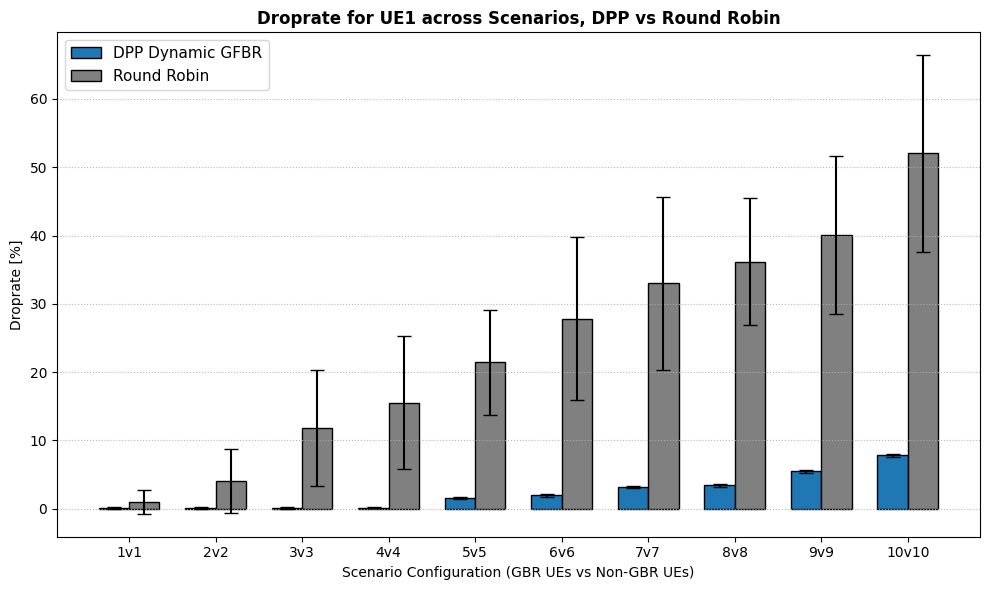

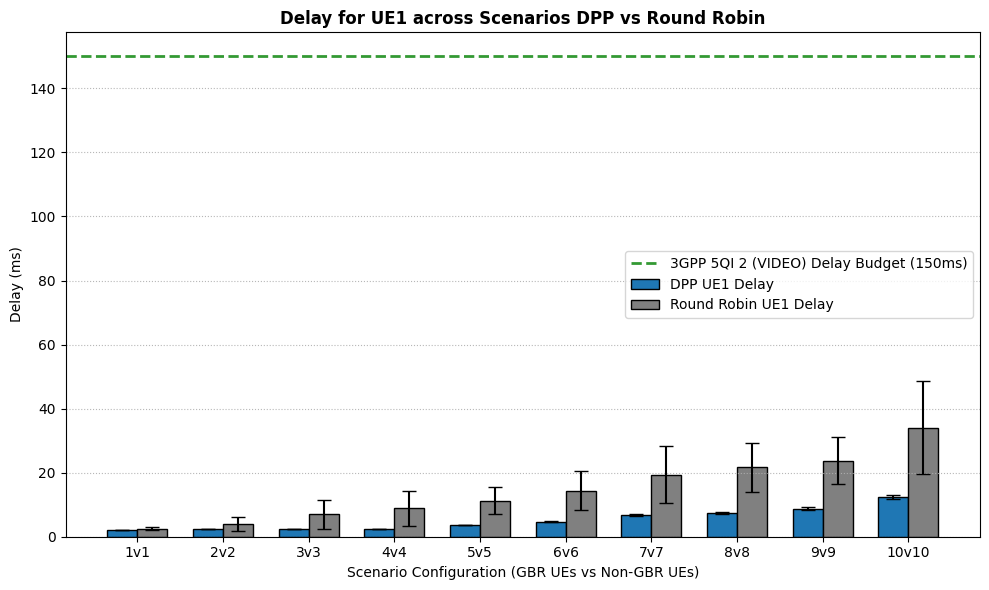

In [1]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Define the scenarios we simulated
scenarios = range(1, 11)
x_labels = [f"{i}v{i}" for i in scenarios]  # Creates labels like "1v1", "2v2", etc.

total_served_DPP = []
total_served_RR = []

simulations = range(1, 11)
buffer = 937500
file_dir = f'final_results/buffer_{buffer}bps/'
savefigs= f'FIGS/{file_dir}'
save = True

if not os.path.exists(savefigs) and save:
    os.makedirs(savefigs)

thr_results_dpp = np.zeros((len(scenarios), len(simulations)))
thr_results_rr = np.zeros((len(scenarios), len(simulations)))

# ######### Throughput CALCULATION ################################

print("📊 Analyzing simulation results...")

for i in scenarios:
    for j in simulations:
        # Match the unified CSV name from your TMUX script
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)']
        served_DPP = normalized_throughput_ue_1.mean()
        total_served_DPP.append(served_DPP)
        thr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)']
        served_RR = normalized_throughput_RR.mean()
        total_served_RR.append(served_RR)
        thr_results_rr[i-1, j-1] = served_RR

plt.figure(figsize=(10, 6))

# Bar plot setup
x = np.arange(len(x_labels))  # the label locations
width = 0.35  # the width of the bars

# Calculate means and standard deviations
mean_thr_dpp = thr_results_dpp.mean(axis=1)
std_thr_dpp = thr_results_dpp.std(axis=1)
mean_thr_rr = thr_results_rr.mean(axis=1)
std_thr_rr = thr_results_rr.std(axis=1)

# Plot bars with error bars
plt.bar(x - width/2, mean_thr_dpp, width, yerr=std_thr_dpp, capsize=5, 
        color='tab:blue', label='DPP Dynamic GFBR', edgecolor='black')
plt.bar(x + width/2, mean_thr_rr, width, yerr=std_thr_rr, capsize=5, 
        color='gray', label='Round Robin', edgecolor='black')

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Served Throughput (Mbps)')
plt.xticks(x, x_labels)
plt.legend(loc='best', fontsize=11)
plt.grid(True, axis='y', linestyle=':', alpha=0.9)
plt.title('Throughput for UE1 across Scenarios, DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Throughput_DPP_Mean:' , mean_thr_dpp.round(2))
print('Throughput_RR_Mean:' , mean_thr_rr.round(2))


# ######### DROPRATE CALCULATION ################################

dr_results_dpp = np.zeros((len(scenarios), len(simulations)))
dr_results_rr = np.zeros((len(scenarios), len(simulations)))

for i in scenarios:
    for j in simulations:
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic = df_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop = 1 - (normalized_throughput_ue_1 / requested_traffic)
        served_DPP = drop.mean() * 100
        dr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic_RR = df_RR_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop_RR = 1 - (normalized_throughput_RR / requested_traffic_RR)
        served_RR = drop_RR.mean() * 100
        dr_results_rr[i-1, j-1] = served_RR

plt.figure(figsize=(10, 6))

# Calculate means and standard deviations
mean_dr_dpp = dr_results_dpp.mean(axis=1)
std_dr_dpp = dr_results_dpp.std(axis=1)
mean_dr_rr = dr_results_rr.mean(axis=1)
std_dr_rr = dr_results_rr.std(axis=1)

# Plot bars with error bars
plt.bar(x - width/2, mean_dr_dpp, width, yerr=std_dr_dpp, capsize=5, 
        color='tab:blue', label='DPP Dynamic GFBR', edgecolor='black')
plt.bar(x + width/2, mean_dr_rr, width, yerr=std_dr_rr, capsize=5, 
        color='gray', label='Round Robin', edgecolor='black')

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Droprate [%]')
plt.xticks(x, x_labels)
plt.legend(loc='best', fontsize=11)
plt.grid(True, axis='y', linestyle=':', alpha=0.9)
plt.title('Droprate for UE1 across Scenarios, DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Droprate_DPP_Mean:' , mean_dr_dpp.round(2))
print('Droprate_RR_Mean:' , mean_dr_rr.round(2))


# ######### Delay CALCULATION ################################

delay_results_dpp = np.zeros((len(scenarios), len(simulations)))
delay_results_rr = np.zeros((len(scenarios), len(simulations)))

for i in scenarios:
    for j in simulations:
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        
        normalized_delay_ue_1 = df_ue_id_1['MeasuredDelay(ms)'].mean()
        delay_results_dpp[i-1, j-1] = normalized_delay_ue_1

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        
        delay_mean_RR = df_RR_ue_id_1['MeasuredDelay(ms)'].mean()
        delay_results_rr[i-1, j-1] = delay_mean_RR

plt.figure(figsize=(10, 6))

# Calculate means and standard deviations
mean_delay_dpp = delay_results_dpp.mean(axis=1)
std_delay_dpp = delay_results_dpp.std(axis=1)
mean_delay_rr = delay_results_rr.mean(axis=1)
std_delay_rr = delay_results_rr.std(axis=1)

# Plot bars with error bars
plt.bar(x - width/2, mean_delay_dpp, width, yerr=std_delay_dpp, capsize=5, 
        color='tab:blue', label='DPP UE1 Delay', edgecolor='black')
plt.bar(x + width/2, mean_delay_rr, width, yerr=std_delay_rr, capsize=5, 
        color='gray', label='Round Robin UE1 Delay', edgecolor='black')

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Delay (ms)')
plt.xticks(x, x_labels)

# Add a horizontal dashed line representing a typical 4K video delay limit
plt.axhline(y=150, color='green', linestyle='--', linewidth=2, alpha=0.8, label='3GPP 5QI 2 (VIDEO) Delay Budget (150ms)')

plt.legend(loc='best')
plt.grid(True, axis='y', linestyle=':', alpha=0.9)
plt.title('Delay for UE1 across Scenarios DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Delay_DPP_Mean:' , mean_delay_dpp.round(2))
print('Delay_RR_Mean:' , mean_delay_rr.round(2))

📊 Analyzing simulation results...
Throughput_DPP_Mean: [25.88 25.88 25.88 25.88 25.53 25.42 25.1  25.04 24.5  23.9 ]
Throughput_RR_Mean: [25.67 24.88 22.86 21.9  20.36 18.72 17.37 16.55 15.53 12.44]
Droprate_DPP_Mean: [0.16 0.17 0.18 0.17 1.52 1.96 3.18 3.42 5.48 7.8 ]
Droprate_RR_Mean: [ 0.98  4.03 11.82 15.53 21.45 27.78 32.99 36.17 40.08 52.01]
Delay_DPP_Mean: [ 2.22  2.35  2.45  2.56  3.63  4.74  6.78  7.45  8.68 12.39]
Delay_RR_Mean: [ 2.47  3.92  7.06  8.86 11.19 14.42 19.4  21.64 23.74 34.06]
Delay_DPP_p95: [ 3.11  3.51  3.69  3.92  5.18  6.53  7.87 18.97 33.11 43.68]
Delay_RR_p95: [  3.77  11.48  27.73  43.39  64.15  79.34 106.72 121.12 131.42 181.98]


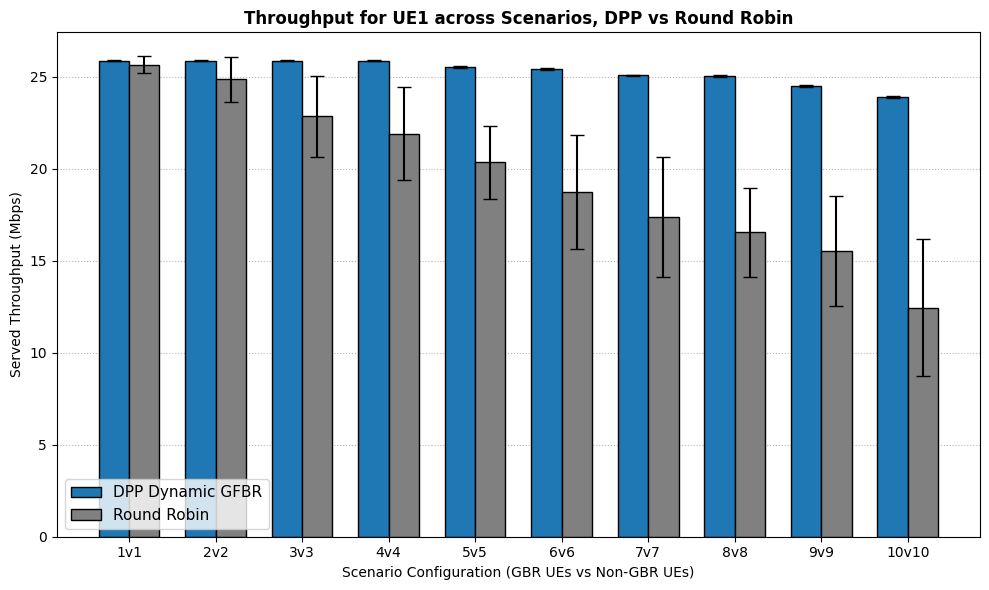

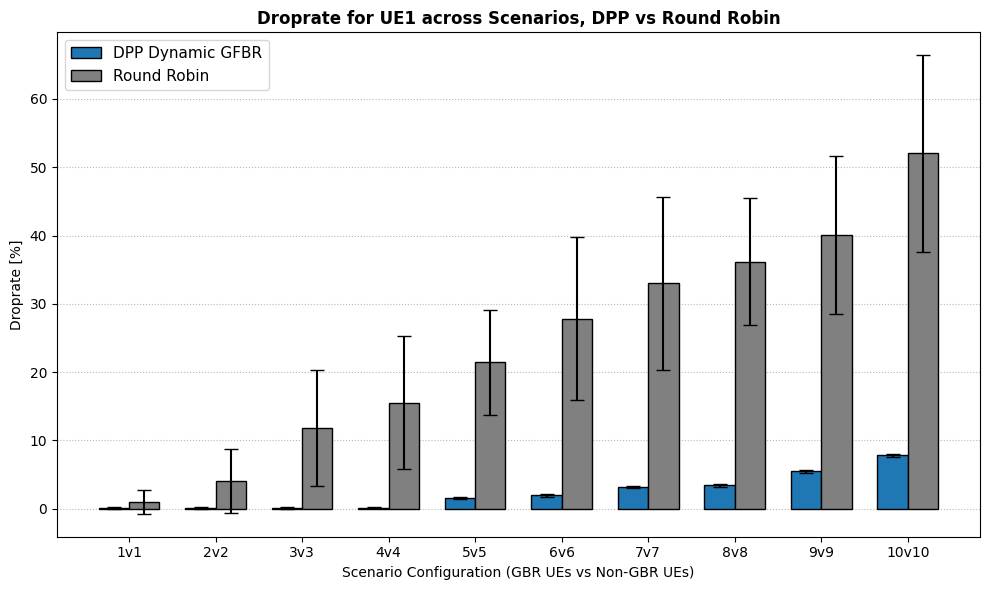

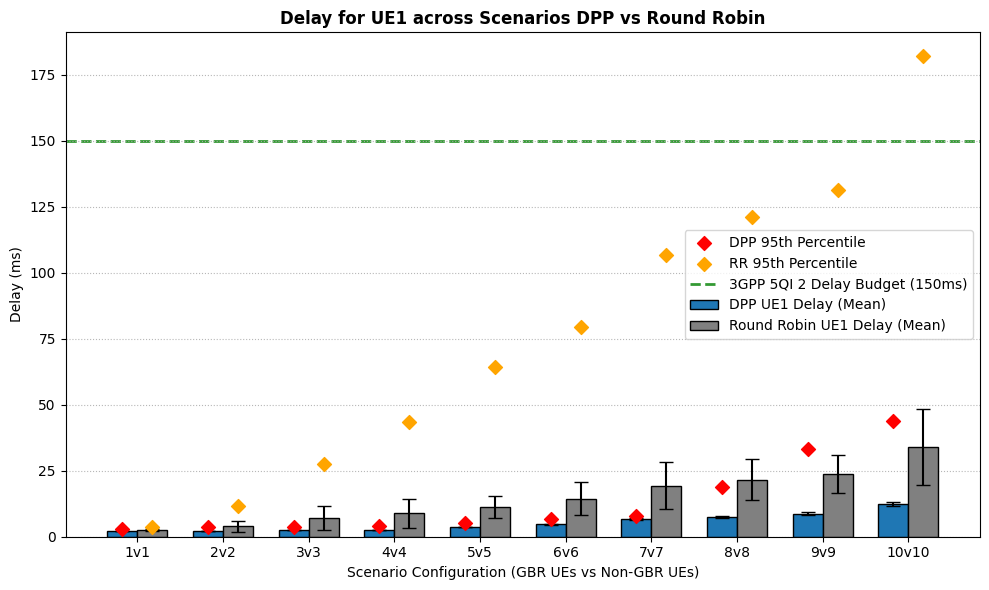

In [4]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# Define the scenarios we simulated
scenarios = range(1, 11)
x_labels = [f"{i}v{i}" for i in scenarios]  # Creates labels like "1v1", "2v2", etc.

total_served_DPP = []
total_served_RR = []

simulations = range(1, 11)
buffer = 937500
file_dir = f'final_results/buffer_{buffer}bps/'
savefigs= f'FIGS/{file_dir}'
save = True

if not os.path.exists(savefigs) and save:
    os.makedirs(savefigs)

# Helper variables for bar plots
x = np.arange(len(x_labels))  # the label locations
width = 0.35  # the width of the bars

# ######### Throughput CALCULATION ################################

thr_results_dpp = np.zeros((len(scenarios), len(simulations)))
thr_results_rr = np.zeros((len(scenarios), len(simulations)))

print("📊 Analyzing simulation results...")

for i in scenarios:
    for j in simulations:
        # Match the unified CSV name from your TMUX script
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)']
        served_DPP = normalized_throughput_ue_1.mean()
        total_served_DPP.append(served_DPP)
        thr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)']
        served_RR = normalized_throughput_RR.mean()
        total_served_RR.append(served_RR)
        thr_results_rr[i-1, j-1] = served_RR

plt.figure(figsize=(10, 6))

# Calculate means and standard deviations
mean_thr_dpp = thr_results_dpp.mean(axis=1)
std_thr_dpp = thr_results_dpp.std(axis=1)
mean_thr_rr = thr_results_rr.mean(axis=1)
std_thr_rr = thr_results_rr.std(axis=1)

# Plot bars with error bars
plt.bar(x - width/2, mean_thr_dpp, width, yerr=std_thr_dpp, capsize=5, 
        color='tab:blue', label='DPP Dynamic GFBR', edgecolor='black', zorder=2)
plt.bar(x + width/2, mean_thr_rr, width, yerr=std_thr_rr, capsize=5, 
        color='gray', label='Round Robin', edgecolor='black', zorder=2)

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Served Throughput (Mbps)')
plt.xticks(x, x_labels)
plt.legend(loc='best', fontsize=11)
plt.grid(True, axis='y', linestyle=':', alpha=0.9, zorder=0)
plt.title('Throughput for UE1 across Scenarios, DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/throughput_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Throughput_DPP_Mean:' , mean_thr_dpp.round(2))
print('Throughput_RR_Mean:' , mean_thr_rr.round(2))


# ######### DROPRATE CALCULATION ################################

dr_results_dpp = np.zeros((len(scenarios), len(simulations)))
dr_results_rr = np.zeros((len(scenarios), len(simulations)))

for i in scenarios:
    for j in simulations:
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        normalized_throughput_ue_1 =df_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic = df_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop = 1 - (normalized_throughput_ue_1 / requested_traffic)
        served_DPP = drop.mean() * 100
        dr_results_dpp[i-1, j-1] = served_DPP

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        normalized_throughput_RR = df_RR_ue_id_1['MeasuredThroughput(Mbps)'].mean()
        requested_traffic_RR = df_RR_ue_id_1['TargetTraffic(Mbps)'].mean()
        drop_RR = 1 - (normalized_throughput_RR / requested_traffic_RR)
        served_RR = drop_RR.mean() * 100
        dr_results_rr[i-1, j-1] = served_RR

plt.figure(figsize=(10, 6))

# Calculate means and standard deviations
mean_dr_dpp = dr_results_dpp.mean(axis=1).clip(0, 100)  # Ensure droprate is between 0% and 100%
std_dr_dpp = dr_results_dpp.std(axis=1).clip(0, 100)
mean_dr_rr = dr_results_rr.mean(axis=1).clip(0, 100)
std_dr_rr = dr_results_rr.std(axis=1).clip(0, 100)

# Plot bars with error bars
plt.bar(x - width/2, mean_dr_dpp, width, yerr=std_dr_dpp, capsize=5, 
        color='tab:blue', label='DPP Dynamic GFBR', edgecolor='black', zorder=2)
plt.bar(x + width/2, mean_dr_rr, width, yerr=std_dr_rr, capsize=5, 
        color='gray', label='Round Robin', edgecolor='black', zorder=2)

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Droprate [%]')
plt.xticks(x, x_labels)
plt.legend(loc='best', fontsize=11)
plt.grid(True, axis='y', linestyle=':', alpha=0.9, zorder=0)
plt.title('Droprate for UE1 across Scenarios, DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/droprate_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Droprate_DPP_Mean:' , mean_dr_dpp.round(2))
print('Droprate_RR_Mean:' , mean_dr_rr.round(2))


# ######### Delay CALCULATION ################################

delay_results_dpp = np.zeros((len(scenarios), len(simulations)))
delay_results_rr = np.zeros((len(scenarios), len(simulations)))

# Arrays to store the 95th percentiles
quantile_95_dpp = np.zeros((len(scenarios), len(simulations)))
quantile_95_rr = np.zeros((len(scenarios), len(simulations)))

for i in scenarios:
    for j in simulations:
        filename_DPP = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_DPP_100.0MHz.csv"
        df = pd.read_csv(filename_DPP)
        df = df[df['Time(s)'] > 0.4]
        df_ue_id_1 = df[df['UE_ID'] == 1]
        
        normalized_delay_ue_1 = df_ue_id_1['MeasuredDelay(ms)'].mean()
        delay_results_dpp[i-1, j-1] = normalized_delay_ue_1
        quantile_95_dpp[i-1, j-1] = df_ue_id_1['MeasuredDelay(ms)'].quantile(0.95)

        filename_RR = f"{file_dir}/sim_{j}/unified_stats_scenario_{i}gbr_{i}nongbr_4K_sorted_maximum_traffic_RR_100.0MHz.csv"
        df_RR = pd.read_csv(filename_RR)
        df_RR = df_RR[df_RR['Time(s)'] > 0.4]
        df_RR_ue_id_1 = df_RR[df_RR['UE_ID'] == 1]
        
        delay_mean_RR = df_RR_ue_id_1['MeasuredDelay(ms)'].mean()
        delay_results_rr[i-1, j-1] = delay_mean_RR
        quantile_95_rr[i-1, j-1] = df_RR_ue_id_1['MeasuredDelay(ms)'].quantile(0.95)

plt.figure(figsize=(10, 6))

# Calculate means and standard deviations for the main bars
mean_delay_dpp = delay_results_dpp.mean(axis=1)
std_delay_dpp = delay_results_dpp.std(axis=1)
mean_delay_rr = delay_results_rr.mean(axis=1)
std_delay_rr = delay_results_rr.std(axis=1)

# Calculate the mean of the 95th percentiles across simulations
mean_p95_dpp = quantile_95_dpp.mean(axis=1)
mean_p95_rr = quantile_95_rr.mean(axis=1)

# Plot bars with error bars
plt.bar(x - width/2, mean_delay_dpp, width, yerr=std_delay_dpp, capsize=5, 
        color='tab:blue', label='DPP UE1 Delay (Mean)', edgecolor='black', zorder=2)
plt.bar(x + width/2, mean_delay_rr, width, yerr=std_delay_rr, capsize=5, 
        color='gray', label='Round Robin UE1 Delay (Mean)', edgecolor='black', zorder=2)

# Overlay the 95th percentile as scatter points (Diamonds)
plt.scatter(x - width/2, mean_p95_dpp, color='red', marker='D', s=50, zorder=3, label='DPP 95th Percentile')
plt.scatter(x + width/2, mean_p95_rr, color='orange', marker='D', s=50, zorder=3, label='RR 95th Percentile')

plt.xlabel('Scenario Configuration (GBR UEs vs Non-GBR UEs)')
plt.ylabel('Delay (ms)')
plt.xticks(x, x_labels)

# Add a horizontal dashed line representing a typical 4K video delay limit
plt.axhline(y=150, color='green', linestyle='--', linewidth=2, alpha=0.8, label='3GPP 5QI 2 Delay Budget (150ms)', zorder=1)

plt.legend(loc='best')
plt.grid(True, axis='y', linestyle=':', alpha=0.9, zorder=0)
plt.title('Delay for UE1 across Scenarios DPP vs Round Robin', fontweight='bold')

plt.tight_layout()
if save:
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE_bar.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{savefigs}/delay_comparison_{simulations[-1]*2}_UE_bar.pdf', dpi=300, bbox_inches='tight')

print('Delay_DPP_Mean:' , mean_delay_dpp.round(2))
print('Delay_RR_Mean:' , mean_delay_rr.round(2))
print('Delay_DPP_p95:' , mean_p95_dpp.round(2))
print('Delay_RR_p95:' , mean_p95_rr.round(2))

In [5]:
std_dr_rr

array([ 1.71842485,  4.7110031 ,  8.50234889,  9.76029585,  7.66924281,
       11.93019795, 12.61667234,  9.33186607, 11.56974817, 14.38099688])